# OMEGA — Ontario Multi-Objective Energy Grid Analyzer

**Forecasting Module:** GBM + RF + LSTM → Ridge Meta-Learner  
**Split:** 90% Train | 5% Validation | 5% Test  
**Order:** CV → Experiments (val set) → Final training → Test evaluation

| Step | Description |
|------|-------------|
| 1 | Imports |
| 2 | Load Dataset |
| 3 | Features + Split |
| 4 | GBM Cross-Validation (5-fold) |
| 5 | RF Cross-Validation (5-fold) |
| 6 | GBM Experiments (4 configs, val set) |
| 7 | RF Experiments (4 configs, val set) |
| 8 | Final GBM + RF Training (best params) |
| 9 | LSTM Cross-Validation (3-fold) |
| 10 | LSTM Final Training |
| 11 | CV Summary Table (GBM + RF + LSTM) |
| 12 | Ridge Meta-Learner |
| 13 | Final Metrics + Evaluation |
| 14 | Predict Date + Export to MILP |

---
## Step 1 — Imports

In [6]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

from sklearn.ensemble  import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics   import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing   import MinMaxScaler

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print('=' * 62)
print('  OMEGA — Ontario Multi-Objective Energy Grid Analyzer')
print('  GBM + RF + LSTM  →  Ridge Meta-Learner')
print('  Split: 90% Train | 5% Validation | 5% Test')
print('=' * 62)
print(f'  TensorFlow : {tf.__version__}')
print(f'  NumPy      : {np.__version__}')
print(f'  Pandas     : {pd.__version__}')

  OMEGA — Ontario Multi-Objective Energy Grid Analyzer
  GBM + RF + LSTM  →  Ridge Meta-Learner
  Split: 90% Train | 5% Validation | 5% Test
  TensorFlow : 2.21.0
  NumPy      : 2.4.6
  Pandas     : 3.0.3


---
## Step 2 — Load Dataset

In [7]:
DATASET_PATH = 'merged_ontario_energy_dataset.csv'

df = pd.read_csv(DATASET_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])
df['season_num'] = df['season'].map(
    {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
)

print(f'  Rows    : {len(df):,}')
print(f'  Columns : {len(df.columns)}')
print(f'  Range   : {df["datetime"].min().date()}  →  {df["datetime"].max().date()}')
print(f'  Targets : ontario_demand_mw | solar_mw | wind_mw')

  Rows    : 96,264
  Columns : 47
  Range   : 2015-01-08  →  2025-12-31
  Targets : ontario_demand_mw | solar_mw | wind_mw


---
## Step 3 — Features + Chronological Split  (90 / 5 / 5)

In [8]:
# ── Feature sets per target ──────────────────────────────────────────
DEMAND_FEATURES = [
    'hour', 'month', 'day_of_week', 'is_weekend', 'is_peak_hour',
    'temperature_c', 'solar_irradiance_kwh_m2', 'wind_speed_10m_ms',
    'relative_humidity_pct',
    'demand_lag1h', 'demand_lag24h', 'demand_lag168h',
    'demand_roll24h_mean',
    'season_num',
]

SOLAR_FEATURES = [
    'hour', 'month', 'is_weekend', 'is_peak_hour',
    'solar_irradiance_kwh_m2', 'clearsky_solar_kwh_m2',
    'temperature_c', 'relative_humidity_pct',
    'season_num',
]

WIND_FEATURES = [
    'hour', 'month', 'day_of_week', 'is_weekend',
    'wind_speed_10m_ms', 'wind_speed_50m_ms',
    'temperature_c', 'relative_humidity_pct',
    'season_num',
]

SEQ_LEN = 24   # LSTM reads the past 24 hours as one input sequence


def prepare_target(df, features, target_col,
                   train_ratio=0.90, val_ratio=0.05):
    """
    Drop NaN rows, then split chronologically: 90% train / 5% val / 5% test.

    Returns
    -------
    X_tr, X_val, X_te  : feature DataFrames
    y_tr, y_val, y_te  : target Series
    data               : full cleaned DataFrame (for proxy builder)
    """
    data  = df.dropna(subset=features + [target_col]).reset_index(drop=True)
    n     = len(data)
    i_tr  = int(n * train_ratio)
    i_val = int(n * (train_ratio + val_ratio))

    X_tr  = data.iloc[:i_tr][features]
    X_val = data.iloc[i_tr:i_val][features]
    X_te  = data.iloc[i_val:][features]

    y_tr  = data.iloc[:i_tr][target_col]
    y_val = data.iloc[i_tr:i_val][target_col]
    y_te  = data.iloc[i_val:][target_col]

    return X_tr, X_val, X_te, y_tr, y_val, y_te, data


# ── Apply split to each target ───────────────────────────────────────
(
    X_d_tr, X_d_val, X_d_te,
    y_d_tr, y_d_val, y_d_te,
    demand_data
) = prepare_target(df, DEMAND_FEATURES, 'ontario_demand_mw')

(
    X_s_tr, X_s_val, X_s_te,
    y_s_tr, y_s_val, y_s_te,
    solar_data
) = prepare_target(df, SOLAR_FEATURES, 'solar_mw')

(
    X_w_tr, X_w_val, X_w_te,
    y_w_tr, y_w_val, y_w_te,
    wind_data
) = prepare_target(df, WIND_FEATURES, 'wind_mw')


# ── Summary ──────────────────────────────────────────────────────────
print('  90 / 5 / 5 Chronological Split')
print(f'  {"Target":<10}  {"Train":>10}  {"Validation":>12}  {"Test":>10}')
print(f'  {"-"*48}')
for label, X_tr, X_val, X_te in [
    ('Demand', X_d_tr, X_d_val, X_d_te),
    ('Solar',  X_s_tr, X_s_val, X_s_te),
    ('Wind',   X_w_tr, X_w_val, X_w_te),
]:
    print(f'  {label:<10}  {len(X_tr):>10,}  {len(X_val):>12,}  {len(X_te):>10,}')

  90 / 5 / 5 Chronological Split
  Target           Train    Validation        Test
  ------------------------------------------------
  Demand          86,637         4,813       4,814
  Solar           86,637         4,813       4,814
  Wind            86,637         4,813       4,814


---
## Step 4 — GBM Cross-Validation  (5-fold, no shuffle, training data only)

Evaluates GBM generalisation **before** any parameter choices. Test set is never touched here.

In [9]:
def mape_score(y_true, y_pred, threshold=1.0):
    import numpy as np
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = y_true > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("  mape_score defined early ✓")


  mape_score defined early ✓


In [10]:
# 5-fold CV on training data only — test set never touched
from sklearn.model_selection import KFold
kf5 = KFold(n_splits=5, shuffle=False)
GBM_CV_PARAMS = dict(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)

print("  Step 4 — GBM Cross-Validation (5-fold, training data only)")
print(f"  {'-'*60}")
gbm_cv_summary = {}
for label, X_tr, y_tr in [('Demand', X_d_tr, y_d_tr), ('Solar', X_s_tr, y_s_tr), ('Wind', X_w_tr, y_w_tr)]:
    fold_r2, fold_mae, fold_mape = [], [], []
    for tr_idx, val_idx in kf5.split(X_tr):
        Xf_tr, Xf_va = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        yf_tr, yf_va = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
        m = GradientBoostingRegressor(**GBM_CV_PARAMS)
        m.fit(Xf_tr, yf_tr)
        preds = m.predict(Xf_va)
        fold_r2.append(r2_score(yf_va, preds))
        fold_mae.append(mean_absolute_error(yf_va, preds))
        fold_mape.append(mape_score(yf_va.values, preds))
    gbm_cv_summary[label] = {
        'R2':   (np.mean(fold_r2),   np.std(fold_r2)),
        'MAE':  (np.mean(fold_mae),  np.std(fold_mae)),
        'MAPE': (np.mean(fold_mape), np.std(fold_mape)),
    }
    print(f"  {label:<8}  R2: {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}  "
          f"MAE: {np.mean(fold_mae):>8.1f} +/- {np.std(fold_mae):.1f} MW  "
          f"MAPE: {np.mean(fold_mape):.2f} +/- {np.std(fold_mape):.2f}%")
print(f"  {'-'*60}")
print("  GBM CV done — test set untouched ✓")


  Step 4 — GBM Cross-Validation (5-fold, training data only)
  ------------------------------------------------------------
  Demand    R2: 0.891 +/- 0.000  MAE:    242.3 +/- 0.4 MW  MAPE: 1.54 +/- 0.00%
  Solar     R2: 0.979 +/- 0.000  MAE:     67.9 +/- 0.4 MW  MAPE: 62.40 +/- 1.80%
  Wind      R2: 0.274 +/- 0.007  MAE:    398.2 +/- 2.1 MW  MAPE: 86.02 +/- 3.31%
  ------------------------------------------------------------
  GBM CV done — test set untouched ✓


---
## Step 5 — RF Cross-Validation  (5-fold, no shuffle, training data only)

Same approach as GBM CV — training data only, test set untouched.

In [11]:
# 5-fold CV on training data only — test set never touched
RF_CV_PARAMS = dict(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)

print("  Step 5 — RF Cross-Validation (5-fold, training data only)")
print(f"  {'-'*60}")
rf_cv_summary = {}
for label, X_tr, y_tr in [('Demand', X_d_tr, y_d_tr), ('Solar', X_s_tr, y_s_tr), ('Wind', X_w_tr, y_w_tr)]:
    fold_r2, fold_mae, fold_mape = [], [], []
    for tr_idx, val_idx in kf5.split(X_tr):
        Xf_tr, Xf_va = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        yf_tr, yf_va = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
        m = RandomForestRegressor(**RF_CV_PARAMS)
        m.fit(Xf_tr, yf_tr)
        preds = m.predict(Xf_va)
        fold_r2.append(r2_score(yf_va, preds))
        fold_mae.append(mean_absolute_error(yf_va, preds))
        fold_mape.append(mape_score(yf_va.values, preds))
    rf_cv_summary[label] = {
        'R2':   (np.mean(fold_r2),   np.std(fold_r2)),
        'MAE':  (np.mean(fold_mae),  np.std(fold_mae)),
        'MAPE': (np.mean(fold_mape), np.std(fold_mape)),
    }
    print(f"  {label:<8}  R2: {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}  "
          f"MAE: {np.mean(fold_mae):>8.1f} +/- {np.std(fold_mae):.1f} MW  "
          f"MAPE: {np.mean(fold_mape):.2f} +/- {np.std(fold_mape):.2f}%")
print(f"  {'-'*60}")
print("  RF CV done — test set untouched ✓")


  Step 5 — RF Cross-Validation (5-fold, training data only)
  ------------------------------------------------------------
  Demand    R2: 0.877 +/- 0.001  MAE:    256.8 +/- 0.7 MW  MAPE: 1.63 +/- 0.00%
  Solar     R2: 0.978 +/- 0.000  MAE:     69.2 +/- 0.5 MW  MAPE: 61.80 +/- 2.11%
  Wind      R2: 0.273 +/- 0.007  MAE:    398.6 +/- 2.2 MW  MAPE: 86.11 +/- 3.47%
  ------------------------------------------------------------
  RF CV done — test set untouched ✓


---
## Step 6 — GBM Hyperparameter Experiments  (4 configs, validation set)

Now that CV has established baseline performance, test 4 parameter configurations. Evaluated on **validation set only** — test set still untouched.

In [12]:
# 4 experiments evaluated on VALIDATION set — test set never touched
GBM_EXPERIMENTS = [
    dict(n_estimators=150, max_depth=5,  learning_rate=0.10, random_state=42),
    dict(n_estimators=100, max_depth=3,  learning_rate=0.05, random_state=42),
    dict(n_estimators=200, max_depth=7,  learning_rate=0.10, random_state=42),
    dict(n_estimators=300, max_depth=5,  learning_rate=0.15, random_state=42),
]

print("  Step 6 — GBM Experiments (4 configs, evaluated on VALIDATION set)")
print(f"  {'-'*72}")
print(f"  {'Exp':<5} {'n_est':>6} {'depth':>6} {'lr':>6}  {'D-MAPE':>8} {'S-MAPE':>8} {'W-MAPE':>8} {'Mean':>8}")
print(f"  {'-'*72}")

gbm_exp_results = []
for i, params in enumerate(GBM_EXPERIMENTS, 1):
    d_m = GradientBoostingRegressor(**params).fit(X_d_tr, y_d_tr)
    s_m = GradientBoostingRegressor(**params).fit(X_s_tr, y_s_tr)
    w_m = GradientBoostingRegressor(**params).fit(X_w_tr, y_w_tr)
    d_mape = mape_score(y_d_val.values, d_m.predict(X_d_val))
    s_mape = mape_score(y_s_val.values, s_m.predict(X_s_val))
    w_mape = mape_score(y_w_val.values, w_m.predict(X_w_val))
    mean_m = (d_mape + s_mape + w_mape) / 3
    gbm_exp_results.append({'exp':i,'params':params,'mean':mean_m,'models':(d_m,s_m,w_m)})
    print(f"  Exp {i:<3} {params['n_estimators']:>6} {params['max_depth']:>6} "
          f"{params['learning_rate']:>6.2f}  "
          f"{d_mape:>7.2f}%  {s_mape:>7.2f}%  {w_mape:>7.2f}%  {mean_m:>7.2f}%")

best_gbm   = min(gbm_exp_results, key=lambda x: x['mean'])
GBM_PARAMS = best_gbm['params']
print(f"  {'-'*72}")
print(f"  Best: Experiment {best_gbm['exp']}  (val mean MAPE {best_gbm['mean']:.2f}%)")
print(f"  Selected: {GBM_PARAMS}")


  Step 6 — GBM Experiments (4 configs, evaluated on VALIDATION set)
  ------------------------------------------------------------------------
  Exp    n_est  depth     lr    D-MAPE   S-MAPE   W-MAPE     Mean
  ------------------------------------------------------------------------
  Exp 1      150      5   0.10     1.51%    75.26%    79.00%    51.92%
  Exp 2      100      3   0.05     1.66%    97.70%    79.54%    59.63%
  Exp 3      200      7   0.10     1.51%    73.87%    79.65%    51.68%
  Exp 4      300      5   0.15     1.50%    77.24%    79.01%    52.58%
  ------------------------------------------------------------------------
  Best: Experiment 3  (val mean MAPE 51.68%)
  Selected: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'random_state': 42}


---
## Step 7 — RF Hyperparameter Experiments  (4 configs, validation set)

In [13]:
# 4 experiments evaluated on VALIDATION set — test set never touched
RF_EXPERIMENTS = [
    dict(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    dict(n_estimators=100, max_depth=5,  random_state=42, n_jobs=-1),
    dict(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    dict(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
]

print("  Step 7 — RF Experiments (4 configs, evaluated on VALIDATION set)")
print(f"  {'-'*72}")
print(f"  {'Exp':<5} {'n_est':>6} {'depth':>6}  {'D-MAPE':>8} {'S-MAPE':>8} {'W-MAPE':>8} {'Mean':>8}")
print(f"  {'-'*72}")

rf_exp_results = []
for i, params in enumerate(RF_EXPERIMENTS, 1):
    d_m = RandomForestRegressor(**params).fit(X_d_tr, y_d_tr)
    s_m = RandomForestRegressor(**params).fit(X_s_tr, y_s_tr)
    w_m = RandomForestRegressor(**params).fit(X_w_tr, y_w_tr)
    d_mape = mape_score(y_d_val.values, d_m.predict(X_d_val))
    s_mape = mape_score(y_s_val.values, s_m.predict(X_s_val))
    w_mape = mape_score(y_w_val.values, w_m.predict(X_w_val))
    mean_m = (d_mape + s_mape + w_mape) / 3
    rf_exp_results.append({'exp':i,'params':params,'mean':mean_m,'models':(d_m,s_m,w_m)})
    print(f"  Exp {i:<3} {params['n_estimators']:>6} {params['max_depth']:>6}  "
          f"{d_mape:>7.2f}%  {s_mape:>7.2f}%  {w_mape:>7.2f}%  {mean_m:>7.2f}%")

best_rf   = min(rf_exp_results, key=lambda x: x['mean'])
RF_PARAMS = best_rf['params']
print(f"  {'-'*72}")
print(f"  Best: Experiment {best_rf['exp']}  (val mean MAPE {best_rf['mean']:.2f}%)")
print(f"  Selected: {RF_PARAMS}")


  Step 7 — RF Experiments (4 configs, evaluated on VALIDATION set)
  ------------------------------------------------------------------------
  Exp    n_est  depth    D-MAPE   S-MAPE   W-MAPE     Mean
  ------------------------------------------------------------------------
  Exp 1      150     10     1.60%    75.37%    79.37%    52.11%
  Exp 2      100      5     1.85%    87.26%    79.37%    56.16%
  Exp 3      200     15     1.54%    76.87%    80.49%    52.97%
  Exp 4      300     10     1.59%    75.42%    79.28%    52.10%
  ------------------------------------------------------------------------
  Best: Experiment 4  (val mean MAPE 52.10%)
  Selected: {'n_estimators': 300, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}


---
## Step 8 — Final GBM + RF Training  (best params, full training set)

Retrain on full 90% training split with best parameters selected above.

In [14]:
GBM_PARAMS = dict(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

print('  Training GBM base models on training split (90%)...\n')

# ── Demand ───────────────────────────────────────────────────────────
demand_gbm = GradientBoostingRegressor(**GBM_PARAMS)
demand_gbm.fit(X_d_tr, y_d_tr)
gbm_d_tr  = demand_gbm.predict(X_d_tr)
gbm_d_val = demand_gbm.predict(X_d_val)
gbm_d_te  = demand_gbm.predict(X_d_te)
print('  Demand  GBM — done ✓')

# ── Solar ────────────────────────────────────────────────────────────
solar_gbm = GradientBoostingRegressor(**GBM_PARAMS)
solar_gbm.fit(X_s_tr, y_s_tr)
gbm_s_tr  = solar_gbm.predict(X_s_tr)
gbm_s_val = solar_gbm.predict(X_s_val)
gbm_s_te  = solar_gbm.predict(X_s_te)
print('  Solar   GBM — done ✓')

# ── Wind ─────────────────────────────────────────────────────────────
wind_gbm = GradientBoostingRegressor(**GBM_PARAMS)
wind_gbm.fit(X_w_tr, y_w_tr)
gbm_w_tr  = wind_gbm.predict(X_w_tr)
gbm_w_val = wind_gbm.predict(X_w_val)
gbm_w_te  = wind_gbm.predict(X_w_te)
print('  Wind    GBM — done ✓')

RF_PARAMS = dict(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print('  Training RF base models on training split (90%)...\n')

# ── Demand ───────────────────────────────────────────────────────────
demand_rf = RandomForestRegressor(**RF_PARAMS)
demand_rf.fit(X_d_tr, y_d_tr)
rf_d_tr  = demand_rf.predict(X_d_tr)
rf_d_val = demand_rf.predict(X_d_val)
rf_d_te  = demand_rf.predict(X_d_te)
print('  Demand  RF — done ✓')

# ── Solar ────────────────────────────────────────────────────────────
solar_rf = RandomForestRegressor(**RF_PARAMS)
solar_rf.fit(X_s_tr, y_s_tr)
rf_s_tr  = solar_rf.predict(X_s_tr)
rf_s_val = solar_rf.predict(X_s_val)
rf_s_te  = solar_rf.predict(X_s_te)
print('  Solar   RF — done ✓')

# ── Wind ─────────────────────────────────────────────────────────────
wind_rf = RandomForestRegressor(**RF_PARAMS)
wind_rf.fit(X_w_tr, y_w_tr)
rf_w_tr  = wind_rf.predict(X_w_tr)
rf_w_val = wind_rf.predict(X_w_val)
rf_w_te  = wind_rf.predict(X_w_te)
print('  Wind    RF — done ✓')

  Training GBM base models on training split (90%)...

  Demand  GBM — done ✓
  Solar   GBM — done ✓
  Wind    GBM — done ✓
  Training RF base models on training split (90%)...

  Demand  RF — done ✓
  Solar   RF — done ✓
  Wind    RF — done ✓


---
## Step 9 — LSTM Cross-Validation  (3-fold, training data only)

3 folds instead of 5 — each fold trains 3 LSTMs (~10 min each). Early stopping `patience=5` keeps fold training fast. Final LSTM (Step 10) uses full `patience=10` and 100 epochs.

`build_sequences` and `build_lstm` defined here — used by both CV and final training.

In [15]:
def build_sequences(X_scaled, y_arr, seq_len):
    """
    Sliding-window sequence builder for LSTM.

    For each index i >= seq_len, the window [i-seq_len : i] becomes
    one input sample and y_arr[i] becomes its label.

    Parameters
    ----------
    X_scaled : ndarray (n, n_features)  — MinMax scaled
    y_arr    : ndarray (n,)
    seq_len  : int — window size (24 hours)

    Returns
    -------
    X_seq : ndarray (n - seq_len, seq_len, n_features)
    y_seq : ndarray (n - seq_len,)
    """
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X_scaled)):
        X_seq.append(X_scaled[i - seq_len : i])
        y_seq.append(y_arr[i])
    return np.array(X_seq), np.array(y_seq)


def build_lstm(n_features):
    """
    Build and compile the LSTM architecture.
    Two stacked LSTM layers capture both short-term and long-term patterns.
    Dropout layers regularise to prevent overfitting on the training split.
    """
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(SEQ_LEN, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.1),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # increased from 5 — gives LSTM more time to improve
    restore_best_weights=True,
    verbose=0,
)

print('  LSTM utilities defined — build_sequences(), build_lstm().')

  LSTM utilities defined — build_sequences(), build_lstm().


In [16]:
# 3-fold CV on training data only — 3 folds instead of 5 due to training cost
kf3 = KFold(n_splits=3, shuffle=False)

print("  Step 9 — LSTM Cross-Validation (3-fold, training data only)")
print("  Note: 3-fold used — each fold trains 3 LSTMs, ~10 min each")
print(f"  {'-'*60}")

lstm_cv_summary = {}
for label, X_tr, y_tr in [('Demand', X_d_tr, y_d_tr),
                            ('Solar',  X_s_tr, y_s_tr),
                            ('Wind',   X_w_tr, y_w_tr)]:
    fold_r2, fold_mae, fold_mape = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(kf3.split(X_tr), 1):
        Xf_tr_r, Xf_va_r = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        yf_tr_r, yf_va_r = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]

        # Scale X and y separately — same approach as final LSTM training
        sc_X = MinMaxScaler()
        Xf_tr_sc = sc_X.fit_transform(Xf_tr_r)
        Xf_va_sc = sc_X.transform(Xf_va_r)

        sc_y = MinMaxScaler()
        yf_tr_sc = sc_y.fit_transform(yf_tr_r.values.reshape(-1,1)).flatten()
        yf_va_sc = sc_y.transform(yf_va_r.values.reshape(-1,1)).flatten()

        Xf_tr_seq, yf_tr_seq = build_sequences(Xf_tr_sc, yf_tr_sc, SEQ_LEN)
        Xf_va_seq, yf_va_seq = build_sequences(Xf_va_sc, yf_va_sc, SEQ_LEN)

        if len(Xf_tr_seq) < 10 or len(Xf_va_seq) < 2:
            continue

        m = build_lstm(Xf_tr_seq.shape[2])
        es = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=0)
        m.fit(Xf_tr_seq, yf_tr_seq,
              validation_data=(Xf_va_seq, yf_va_seq),
              epochs=50, batch_size=32, callbacks=[es], verbose=0)

        preds_sc = m.predict(Xf_va_seq, verbose=0).flatten()
        preds_mw = sc_y.inverse_transform(preds_sc.reshape(-1,1)).flatten()
        actuals  = yf_va_r.values[SEQ_LEN:]

        fold_r2.append(r2_score(actuals, preds_mw))
        fold_mae.append(mean_absolute_error(actuals, preds_mw))
        fold_mape.append(mape_score(actuals, preds_mw))
        print(f"    {label} fold {fold}: R2={fold_r2[-1]:.3f}  "
              f"MAE={fold_mae[-1]:.1f}  MAPE={fold_mape[-1]:.2f}%")

    lstm_cv_summary[label] = {
        'R2':   (np.mean(fold_r2),   np.std(fold_r2)),
        'MAE':  (np.mean(fold_mae),  np.std(fold_mae)),
        'MAPE': (np.mean(fold_mape), np.std(fold_mape)),
    }
    print(f"  {label:<8}  R2: {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}  "
          f"MAE: {np.mean(fold_mae):>8.1f} +/- {np.std(fold_mae):.1f} MW  "
          f"MAPE: {np.mean(fold_mape):.2f} +/- {np.std(fold_mape):.2f}%")

print(f"  {'-'*60}")
print("  LSTM CV done — test set untouched ✓")


  Step 9 — LSTM Cross-Validation (3-fold, training data only)
  Note: 3-fold used — each fold trains 3 LSTMs, ~10 min each
  ------------------------------------------------------------
    Demand fold 1: R2=0.888  MAE=245.2  MAPE=1.56%
    Demand fold 2: R2=0.886  MAE=245.6  MAPE=1.56%
    Demand fold 3: R2=0.889  MAE=246.6  MAPE=1.58%
  Demand    R2: 0.888 +/- 0.001  MAE:    245.8 +/- 0.6 MW  MAPE: 1.57 +/- 0.01%
    Solar fold 1: R2=0.981  MAE=63.7  MAPE=58.15%
    Solar fold 2: R2=0.980  MAE=67.4  MAPE=66.05%
    Solar fold 3: R2=0.981  MAE=67.7  MAPE=63.34%
  Solar     R2: 0.981 +/- 0.000  MAE:     66.3 +/- 1.8 MW  MAPE: 62.51 +/- 3.28%
    Wind fold 1: R2=0.267  MAE=399.3  MAPE=82.90%
    Wind fold 2: R2=0.285  MAE=398.2  MAPE=89.58%
    Wind fold 3: R2=0.280  MAE=393.7  MAPE=84.25%
  Wind      R2: 0.278 +/- 0.008  MAE:    397.1 +/- 2.4 MW  MAPE: 85.58 +/- 2.88%
  ------------------------------------------------------------
  LSTM CV done — test set untouched ✓


---
## Step 10 — LSTM Final Training  (confirmed architecture, full training set)

CV complete — now train the final LSTM on the full training split. Same architecture as CV folds but with full `patience=10` and 100 epochs max.

In [17]:
print('  Training LSTM base models  (Demand · Solar · Wind)...')
print(f'  Sequence length : {SEQ_LEN} hours')
print('  Architecture    : LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.1) → Dense(1)')
print('  KEY FIX         : y (target) is scaled to [0,1] before training')
print('  Early stopping  : patience=10, 100 epochs max, restore best weights\n')


def train_lstm_target(X_tr, X_val, X_te, y_tr, y_val, y_te, label):
    """
    Scale X and y separately to [0,1] → build sequences → train LSTM →
    inverse-transform predictions back to real MW units.

    KEY FIX: y is now scaled before training.
    Previously y was left as raw MW (10,000–17,000 for demand).
    LSTM's Dense output layer cannot produce values that large reliably
    — its gradients saturate and it learns to predict a constant,
    resulting in val_loss of 213,000,000 and R² of -253.
    Scaling y to [0,1] brings the output into the model's comfortable
    range and allows genuine learning.

    scaler_X : fitted on X_tr only  (no feature leakage)
    scaler_y : fitted on y_tr only  (no target leakage)
    Both returned so predict_date() can reuse them at inference time.

    Val and test sequences use the last SEQ_LEN rows of the preceding
    split as warm-up context so LSTM never starts cold at a boundary.
    """
    # ── Scale X — fit on training only ────────────────────────────────
    scaler_X = MinMaxScaler()
    X_tr_sc  = scaler_X.fit_transform(X_tr.values)
    X_val_sc = scaler_X.transform(X_val.values)
    X_te_sc  = scaler_X.transform(X_te.values)

    # ── Scale y — THE FIX ────────────────────────────────────────────
    scaler_y = MinMaxScaler()
    y_tr_sc  = scaler_y.fit_transform(
                   y_tr.values.reshape(-1, 1)).flatten()
    y_val_sc = scaler_y.transform(
                   y_val.values.reshape(-1, 1)).flatten()
    y_te_sc  = scaler_y.transform(
                   y_te.values.reshape(-1, 1)).flatten()

    # ── Build sequences ──────────────────────────────────────────────
    # Training sequences (scaled X and scaled y)
    Xtr_seq, ytr_seq = build_sequences(X_tr_sc, y_tr_sc, SEQ_LEN)

    # Validation — warm-up: last SEQ_LEN rows of training
    X_val_ctx = np.vstack([X_tr_sc[-SEQ_LEN:], X_val_sc])
    y_val_ctx = np.concatenate([y_tr_sc[-SEQ_LEN:], y_val_sc])
    Xval_seq, yval_seq = build_sequences(X_val_ctx, y_val_ctx, SEQ_LEN)

    # Test — warm-up: last SEQ_LEN rows of validation
    X_te_ctx = np.vstack([X_val_sc[-SEQ_LEN:], X_te_sc])
    y_te_ctx = np.concatenate([y_val_sc[-SEQ_LEN:], y_te_sc])
    Xte_seq, yte_seq = build_sequences(X_te_ctx, y_te_ctx, SEQ_LEN)

    print(f'  {label:<8} LSTM — '
          f'train: {Xtr_seq.shape[0]:,} seqs  '
          f'val: {Xval_seq.shape[0]:,} seqs  '
          f'test: {Xte_seq.shape[0]:,} seqs')

    # ── Train ────────────────────────────────────────────────────────────
    model = build_lstm(Xtr_seq.shape[2])
    hist  = model.fit(
        Xtr_seq, ytr_seq,
        validation_data=(Xval_seq, yval_seq),
        epochs=100,           # increased from 50
        batch_size=128,
        callbacks=[early_stop],
        verbose=0,
    )
    best_ep  = int(np.argmin(hist.history['val_loss'])) + 1
    val_loss = min(hist.history['val_loss'])
    print(f'  {label:<8} LSTM — done ✓  '
          f'(best epoch {best_ep}/100 | val_loss = {val_loss:.6f})')

    # ── Predict → inverse-transform back to real MW ─────────────────────
    def predict_mw(seq):
        scaled = model.predict(seq, verbose=0).flatten()
        return scaler_y.inverse_transform(
                   scaled.reshape(-1, 1)).flatten()

    lstm_tr  = predict_mw(Xtr_seq)
    lstm_val = predict_mw(Xval_seq)
    lstm_te  = predict_mw(Xte_seq)

    # ytr_seq is still in scaled [0,1] space — invert for aligned targets
    y_tr_mw = scaler_y.inverse_transform(
                  ytr_seq.reshape(-1, 1)).flatten()

    return (model, scaler_X, scaler_y,
            lstm_tr, lstm_val, lstm_te,
            y_tr_mw, yval_seq, yte_seq)


# ── Train all three targets ────────────────────────────────────────────
(
    demand_lstm, scaler_d_X, scaler_d_y,
    lstm_d_tr, lstm_d_val, lstm_d_te,
    yd_seq_tr, yd_seq_val, yd_seq_te
) = train_lstm_target(
        X_d_tr, X_d_val, X_d_te,
        y_d_tr, y_d_val, y_d_te, 'Demand')

print()

(
    solar_lstm, scaler_s_X, scaler_s_y,
    lstm_s_tr, lstm_s_val, lstm_s_te,
    ys_seq_tr, ys_seq_val, ys_seq_te
) = train_lstm_target(
        X_s_tr, X_s_val, X_s_te,
        y_s_tr, y_s_val, y_s_te, 'Solar')

print()

(
    wind_lstm, scaler_w_X, scaler_w_y,
    lstm_w_tr, lstm_w_val, lstm_w_te,
    yw_seq_tr, yw_seq_val, yw_seq_te
) = train_lstm_target(
        X_w_tr, X_w_val, X_w_te,
        y_w_tr, y_w_val, y_w_te, 'Wind')

print('\n  All 3 LSTM models trained.')

  Training LSTM base models  (Demand · Solar · Wind)...
  Sequence length : 24 hours
  Architecture    : LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.1) → Dense(1)
  KEY FIX         : y (target) is scaled to [0,1] before training
  Early stopping  : patience=10, 100 epochs max, restore best weights

  Demand   LSTM — train: 86,613 seqs  val: 4,813 seqs  test: 4,814 seqs
  Demand   LSTM — done ✓  (best epoch 30/100 | val_loss = 0.002634)

  Solar    LSTM — train: 86,613 seqs  val: 4,813 seqs  test: 4,814 seqs
  Solar    LSTM — done ✓  (best epoch 37/100 | val_loss = 0.001231)

  Wind     LSTM — train: 86,613 seqs  val: 4,813 seqs  test: 4,814 seqs
  Wind     LSTM — done ✓  (best epoch 10/100 | val_loss = 0.018606)

  All 3 LSTM models trained.


---
## Step 11 — Cross-Validation Summary Table  (GBM + RF + LSTM)

In [18]:
# Combined CV summary — GBM + RF + LSTM, mirrors H. Osman et al. Table 6
print("\n" + "="*70)
print("  CROSS-VALIDATION SUMMARY  (training data only, mean +/- std)")
print("="*70)
print(f"  {'Model':<16} {'Target':<8} {'R2 (±std)':>14} {'MAE (±std)':>16} {'MAPE (±std)':>16}")
print("  " + "-"*66)

for model_name, summary in [('GBM (5-fold)',  gbm_cv_summary),
                              ('RF  (5-fold)',  rf_cv_summary),
                              ('LSTM (3-fold)', lstm_cv_summary)]:
    for j, target in enumerate(['Demand', 'Solar', 'Wind']):
        r2_m,  r2_s  = summary[target]['R2']
        mae_m, mae_s = summary[target]['MAE']
        mp_m,  mp_s  = summary[target]['MAPE']
        label = model_name if j == 0 else ''
        print(f"  {label:<16} {target:<8} "
              f"{r2_m:>6.3f} +/- {r2_s:.3f}  "
              f"{mae_m:>7.1f} +/- {mae_s:.1f}  "
              f"{mp_m:>6.2f} +/- {mp_s:.2f}%")
    print("  " + "-"*66)

print("="*70)
print("  GBM/RF: 5-fold CV  |  LSTM: 3-fold CV (reduced — training cost)")
print("  Test set (5%) untouched — used once at Step 12 final evaluation.")



  CROSS-VALIDATION SUMMARY  (training data only, mean +/- std)
  Model            Target        R2 (±std)       MAE (±std)      MAPE (±std)
  ------------------------------------------------------------------
  GBM (5-fold)     Demand    0.891 +/- 0.000    242.3 +/- 0.4    1.54 +/- 0.00%
                   Solar     0.979 +/- 0.000     67.9 +/- 0.4   62.40 +/- 1.80%
                   Wind      0.274 +/- 0.007    398.2 +/- 2.1   86.02 +/- 3.31%
  ------------------------------------------------------------------
  RF  (5-fold)     Demand    0.877 +/- 0.001    256.8 +/- 0.7    1.63 +/- 0.00%
                   Solar     0.978 +/- 0.000     69.2 +/- 0.5   61.80 +/- 2.11%
                   Wind      0.273 +/- 0.007    398.6 +/- 2.2   86.11 +/- 3.47%
  ------------------------------------------------------------------
  LSTM (3-fold)    Demand    0.888 +/- 0.001    245.8 +/- 0.6    1.57 +/- 0.01%
                   Solar     0.981 +/- 0.000     66.3 +/- 1.8   62.51 +/- 3.28%
            

---
## Step 12 — Ridge Meta-Learner  (GBM + RF + LSTM → Ridge)

Trained on validation split predictions only — no data leakage into base model training data.

In [19]:
RIDGE_ALPHA = 1.0   # L2 regularisation strength

print('  Building Ridge meta-learner  (GBM + RF + LSTM → Ridge)...')
print(f'  Ridge alpha = {RIDGE_ALPHA}  (L2 regularisation)\n')


def build_ridge_ensemble(label,
                         gbm_val, rf_val, lstm_val, y_val,
                         gbm_tr,  rf_tr,  lstm_tr,  y_tr_seq,
                         gbm_te,  rf_te,  lstm_te,  y_te):
    """
    Train Ridge on validation-split stacked predictions.
    Then apply to training and test stacks for full evaluation.

    Ridge is fitted on the *validation* split so the meta-learner never
    sees the same rows the base models trained on — no data leakage.

    LSTM sequences are shorter than GBM/RF arrays by SEQ_LEN rows
    (sliding window skips the first 24 rows). All arrays are aligned
    to the LSTM length by trimming the first SEQ_LEN rows from GBM/RF.

    Returns: ridge model, predictions (train, val, test), aligned targets
    """
    # ── Align on validation split ────────────────────────────────────
    # LSTM val sequences skip first SEQ_LEN rows — trim GBM/RF to match
    trim = len(gbm_val) - len(lstm_val)
    gbm_val_a = gbm_val[trim:]
    rf_val_a  = rf_val[trim:]
    y_val_a   = y_val.values[trim:]

    # Meta-features for validation (Ridge training)
    meta_val = np.column_stack([gbm_val_a, rf_val_a, lstm_val])

    # Fit Ridge on validation stack
    ridge = Ridge(alpha=RIDGE_ALPHA)
    ridge.fit(meta_val, y_val_a)

    coefs = ridge.coef_
    print(f'  {label:<8} Ridge coef → '
          f'GBM={coefs[0]:.4f}  RF={coefs[1]:.4f}  '
          f'LSTM={coefs[2]:.4f}  intercept={ridge.intercept_:.2f}')

    # ── Predict on training split ────────────────────────────────────
    # LSTM train sequences skip first SEQ_LEN rows — align GBM/RF
    trim_tr = len(gbm_tr) - len(lstm_tr)
    meta_tr = np.column_stack([
        gbm_tr[trim_tr:], rf_tr[trim_tr:], lstm_tr
    ])
    y_tr_aligned = y_tr_seq   # already trimmed by build_sequences
    ens_tr = ridge.predict(meta_tr)

    # ── Predict on validation split ──────────────────────────────────
    ens_val = ridge.predict(meta_val)

    # ── Predict on test split ────────────────────────────────────────
    trim_te = len(gbm_te) - len(lstm_te)
    meta_te = np.column_stack([
        gbm_te[trim_te:], rf_te[trim_te:], lstm_te
    ])
    y_te_aligned = y_te.values[trim_te:]
    ens_te = ridge.predict(meta_te)

    return ridge, ens_tr, ens_val, ens_te, y_tr_aligned, y_val_a, y_te_aligned


(
    ridge_d,
    ens_d_tr, ens_d_val, ens_d_te,
    y_d_tr_aln, y_d_val_aln, y_d_te_aln
) = build_ridge_ensemble(
    'Demand',
    gbm_d_val, rf_d_val, lstm_d_val, y_d_val,
    gbm_d_tr,  rf_d_tr,  lstm_d_tr,  yd_seq_tr,
    gbm_d_te,  rf_d_te,  lstm_d_te,  y_d_te
)

print()

(
    ridge_s,
    ens_s_tr, ens_s_val, ens_s_te,
    y_s_tr_aln, y_s_val_aln, y_s_te_aln
) = build_ridge_ensemble(
    'Solar',
    gbm_s_val, rf_s_val, lstm_s_val, y_s_val,
    gbm_s_tr,  rf_s_tr,  lstm_s_tr,  ys_seq_tr,
    gbm_s_te,  rf_s_te,  lstm_s_te,  y_s_te
)

print()

(
    ridge_w,
    ens_w_tr, ens_w_val, ens_w_te,
    y_w_tr_aln, y_w_val_aln, y_w_te_aln
) = build_ridge_ensemble(
    'Wind',
    gbm_w_val, rf_w_val, lstm_w_val, y_w_val,
    gbm_w_tr,  rf_w_tr,  lstm_w_tr,  yw_seq_tr,
    gbm_w_te,  rf_w_te,  lstm_w_te,  y_w_te
)

print('\n  Ridge meta-learner complete.')

  Building Ridge meta-learner  (GBM + RF + LSTM → Ridge)...
  Ridge alpha = 1.0  (L2 regularisation)

  Demand   Ridge coef → GBM=0.6274  RF=-0.1430  LSTM=0.5172  intercept=-30.87

  Solar    Ridge coef → GBM=-0.0004  RF=0.0655  LSTM=0.9421  intercept=-7.77

  Wind     Ridge coef → GBM=0.2524  RF=0.2679  LSTM=0.4645  intercept=3.09

  Ridge meta-learner complete.


In [29]:
# ══════════════════════════════════════════════════════════════════════
# Step 12b — Save All Trained Models
# Run this ONCE after full training completes.
# For any new date: run imports + data + features + load cell + predict
# ══════════════════════════════════════════════════════════════════════

import joblib, os

MODELS_DIR = 'omega_models'
os.makedirs(MODELS_DIR, exist_ok=True)

# GBM
joblib.dump(demand_gbm, f'{MODELS_DIR}/demand_gbm.pkl')
joblib.dump(solar_gbm,  f'{MODELS_DIR}/solar_gbm.pkl')
joblib.dump(wind_gbm,   f'{MODELS_DIR}/wind_gbm.pkl')

# RF
joblib.dump(demand_rf,  f'{MODELS_DIR}/demand_rf.pkl')
joblib.dump(solar_rf,   f'{MODELS_DIR}/solar_rf.pkl')
joblib.dump(wind_rf,    f'{MODELS_DIR}/wind_rf.pkl')

# Ridge
joblib.dump(ridge_d, f'{MODELS_DIR}/ridge_d.pkl')
joblib.dump(ridge_s, f'{MODELS_DIR}/ridge_s.pkl')
joblib.dump(ridge_w, f'{MODELS_DIR}/ridge_w.pkl')

# LSTM
demand_lstm.save(f'{MODELS_DIR}/demand_lstm.keras')
solar_lstm.save( f'{MODELS_DIR}/solar_lstm.keras')
wind_lstm.save(  f'{MODELS_DIR}/wind_lstm.keras')

# Scalers
joblib.dump(scaler_d_X, f'{MODELS_DIR}/scaler_d_X.pkl')
joblib.dump(scaler_d_y, f'{MODELS_DIR}/scaler_d_y.pkl')
joblib.dump(scaler_s_X, f'{MODELS_DIR}/scaler_s_X.pkl')
joblib.dump(scaler_s_y, f'{MODELS_DIR}/scaler_s_y.pkl')
joblib.dump(scaler_w_X, f'{MODELS_DIR}/scaler_w_X.pkl')
joblib.dump(scaler_w_y, f'{MODELS_DIR}/scaler_w_y.pkl')

# Feature config
joblib.dump({
    'DEMAND_FEATURES': DEMAND_FEATURES,
    'SOLAR_FEATURES':  SOLAR_FEATURES,
    'WIND_FEATURES':   WIND_FEATURES,
    'SEQ_LEN':         SEQ_LEN,
    'GBM_PARAMS':      GBM_PARAMS,
    'RF_PARAMS':       RF_PARAMS,
}, f'{MODELS_DIR}/feature_config.pkl')

print(f'✓ All models saved to {MODELS_DIR}/')
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f'{MODELS_DIR}/{f}') / 1024
    print(f'  {f:<35} {size:>8.1f} KB')

✓ All models saved to omega_models/
  demand_gbm.pkl                         707.3 KB
  demand_lstm.keras                      418.7 KB
  demand_rf.pkl                        20522.9 KB
  feature_config.pkl                       0.5 KB
  ridge_d.pkl                              0.6 KB
  ridge_s.pkl                              0.6 KB
  ridge_w.pkl                              0.6 KB
  scaler_d_X.pkl                           1.2 KB
  scaler_d_y.pkl                           0.7 KB
  scaler_s_X.pkl                           1.0 KB
  scaler_s_y.pkl                           0.7 KB
  scaler_w_X.pkl                           1.0 KB
  scaler_w_y.pkl                           0.7 KB
  solar_gbm.pkl                          684.2 KB
  solar_lstm.keras                       403.7 KB
  solar_rf.pkl                         17161.6 KB
  wind_gbm.pkl                           667.4 KB
  wind_lstm.keras                        403.7 KB
  wind_rf.pkl                          16904.1 KB


---
## Step 13 — Final Metrics + Evaluation  (test set used HERE for the first time)

In [20]:
def mape_score(y_true, y_pred, threshold=1.0):
    """
    MAPE computed only on rows where actual > threshold MW.

    WHY: Solar output is 0 MW at night. Dividing by zero (or near-zero)
    produces astronomically large percentages (e.g. 110 billion %).
    We skip any row where actual <= threshold and compute MAPE only
    on hours where the target is meaningfully non-zero.

    threshold=1.0 MW is the cutoff — anything below 1 MW is excluded.
    For demand this has no effect (demand is always >1 MW).
    For solar this removes night-time zeros.
    For wind this removes near-calm hours.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def compute_metrics(y_true, y_pred):
    """Return MSE, MAPE, MAE, R² as a dict."""
    return {
        'MSE' : mean_squared_error(y_true, y_pred),
        'MAPE': mape_score(y_true, y_pred),
        'MAE' : mean_absolute_error(y_true, y_pred),
        'R2'  : r2_score(y_true, y_pred),
    }


def print_metrics_table(target_label,
                        y_tr, y_te,
                        gbm_tr, gbm_te,
                        rf_tr,  rf_te,
                        lstm_tr, lstm_te,
                        ens_tr,  ens_te,
                        y_tr_aln, y_te_aln):
    """
    Print metrics table and return a DataFrame for plotting.
    GBM / RF use the full split arrays.
    LSTM / Ensemble use SEQ_LEN-trimmed arrays (aligned targets).
    """
    # GBM and RF — full split
    m = {
        'GBM' : {
            'Train': compute_metrics(y_tr.values, gbm_tr),
            'Test' : compute_metrics(y_te.values, gbm_te),
        },
        'RF'  : {
            'Train': compute_metrics(y_tr.values, rf_tr),
            'Test' : compute_metrics(y_te.values, rf_te),
        },
        'LSTM': {
            'Train': compute_metrics(y_tr_aln[:len(lstm_tr)], lstm_tr),
            'Test' : compute_metrics(y_te_aln[:len(lstm_te)], lstm_te),
        },
        'Ridge Ensemble': {
            'Train': compute_metrics(y_tr_aln, ens_tr),
            'Test' : compute_metrics(y_te_aln, ens_te),
        },
    }

    # ── Print ─────────────────────────────────────────────────────────
    W = 80
    print(f'\n  {"─" * W}')
    print(f'  Results — {target_label} (MW)')
    print(f'  {"─" * W}')
    print(f'  {"Metric":<8}  {"GBM":>13}  {"RF":>13}  {"LSTM":>13}  {"Ridge Ensemble":>16}')
    print(f'  {" " * 8}  {"Train  Test":>13}  {"Train  Test":>13}  {"Train  Test":>13}  {"Train    Test":>16}')
    print(f'  {"─" * W}')

    metric_labels = [('MSE', 'MSE', 2), ('MAPE', 'MAPE', 2),
                     ('MAE', 'MAE', 2), ('R2', 'R²', 4)]

    for key, display, dp in metric_labels:
        fmt = f'{{:.{dp}f}}'
        line = f'  {display:<8}'
        for model in ['GBM', 'RF', 'LSTM', 'Ridge Ensemble']:
            tr_val = m[model]['Train'][key]
            te_val = m[model]['Test'][key]
            tr_v = fmt.format(tr_val)
            te_v = fmt.format(te_val)
            line += f'  {tr_v:>6} {te_v:>6}'
        print(line)

    print(f'  {"─" * W}')

    # Build DataFrame for plotting
    rows = []
    for key, display, _ in metric_labels:
        row = {'Metric': display}
        for model in ['GBM', 'RF', 'LSTM', 'Ridge Ensemble']:
            row[f'{model} Train'] = m[model]['Train'][key]
            row[f'{model} Test']  = m[model]['Test'][key]
        rows.append(row)
    return pd.DataFrame(rows).set_index('Metric')


table_demand = print_metrics_table(
    'Demand',
    y_d_tr, y_d_te,
    gbm_d_tr, gbm_d_te,
    rf_d_tr,  rf_d_te,
    lstm_d_tr, lstm_d_te,
    ens_d_tr,  ens_d_te,
    y_d_tr_aln, y_d_te_aln
)

table_solar = print_metrics_table(
    'Solar',
    y_s_tr, y_s_te,
    gbm_s_tr, gbm_s_te,
    rf_s_tr,  rf_s_te,
    lstm_s_tr, lstm_s_te,
    ens_s_tr,  ens_s_te,
    y_s_tr_aln, y_s_te_aln
)

table_wind = print_metrics_table(
    'Wind',
    y_w_tr, y_w_te,
    gbm_w_tr, gbm_w_te,
    rf_w_tr,  rf_w_te,
    lstm_w_tr, lstm_w_te,
    ens_w_tr,  ens_w_te,
    y_w_tr_aln, y_w_te_aln
)


  ────────────────────────────────────────────────────────────────────────────────
  Results — Demand (MW)
  ────────────────────────────────────────────────────────────────────────────────
  Metric              GBM             RF           LSTM    Ridge Ensemble
              Train  Test    Train  Test    Train  Test     Train    Test
  ────────────────────────────────────────────────────────────────────────────────
  MSE       85800.28 92312.40  91384.04 106241.61  91865.94 93145.48  87939.40 90778.06
  MAPE        1.49   1.60    1.53   1.72    1.54   1.61    1.51   1.59
  MAE       233.73 243.15  241.06 260.19  241.92 243.74  236.63 240.84
  R²        0.8988 0.8296  0.8923 0.8039  0.8917 0.8281  0.8963 0.8324
  ────────────────────────────────────────────────────────────────────────────────

  ────────────────────────────────────────────────────────────────────────────────
  Results — Solar (MW)
  ────────────────────────────────────────────────────────────────────────────────
  Me

### Step 8b — Publication-Style Metrics Figure

Renders the metrics tables as a styled PNG figure (layout matches Table 5 in
Prof. Osman et al., 2025). Training columns are blue-tinted; test columns are
red-tinted; Ridge Ensemble columns are highlighted in green/amber.

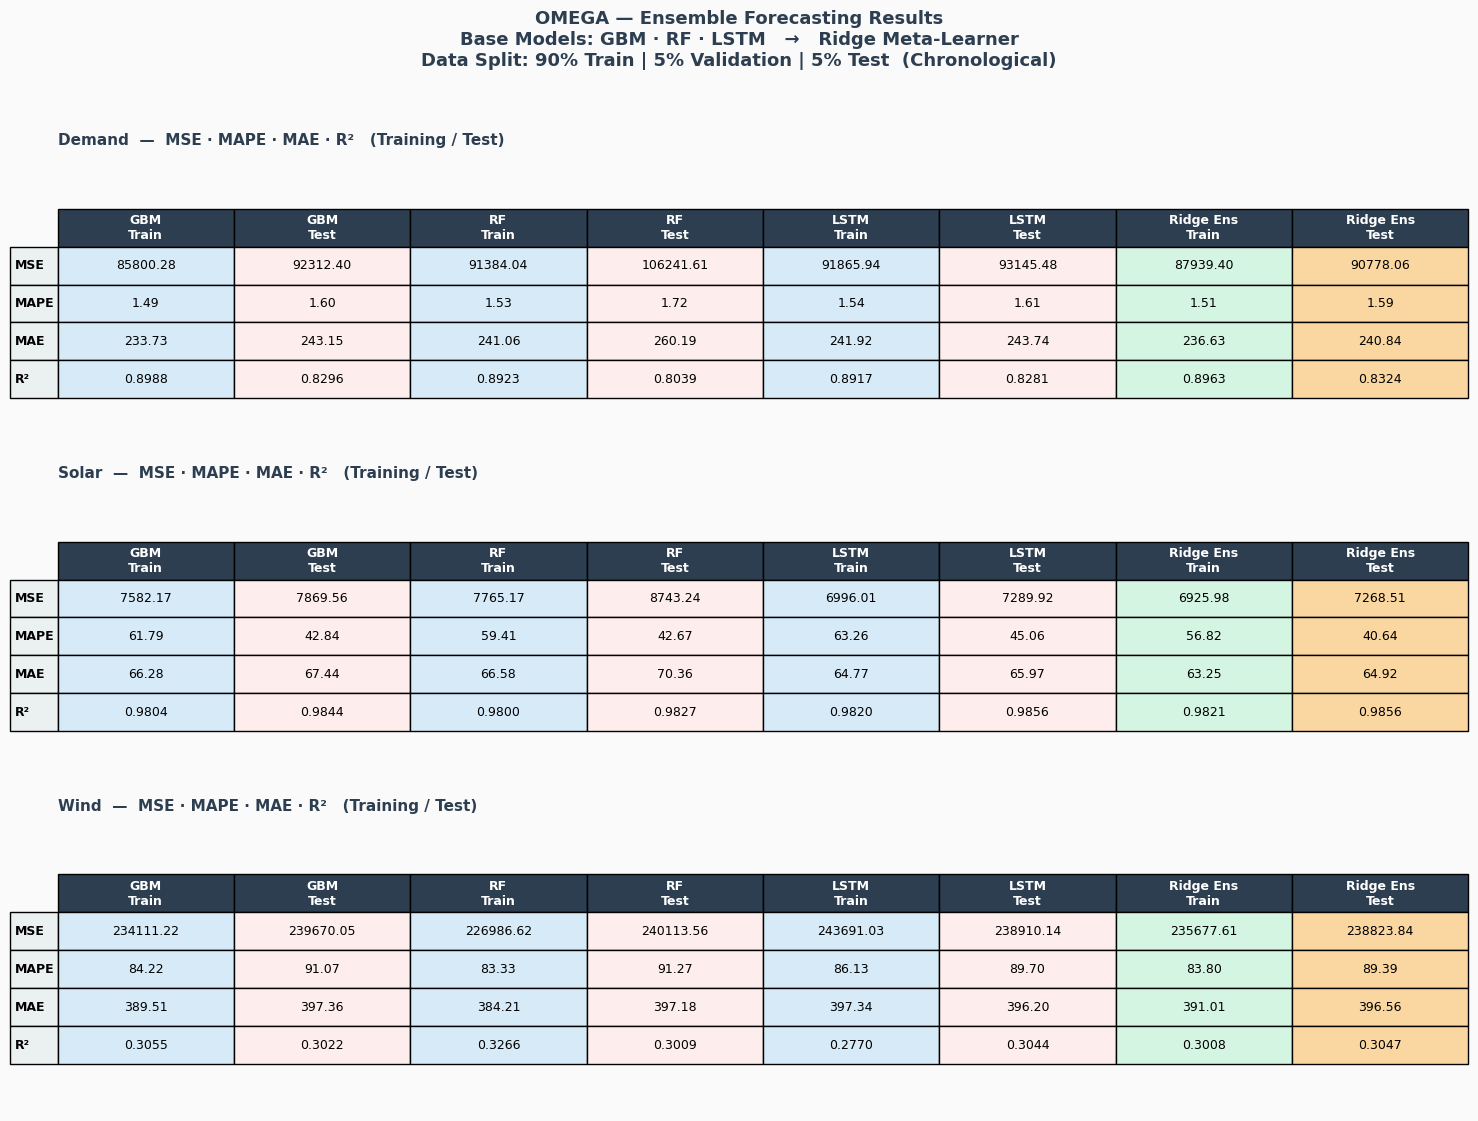

  Figure saved → omega_metrics_table.png


In [21]:
def plot_metrics_figure(tables_dict, save_path='omega_metrics_table.png'):
    """
    Render metrics tables as a publication-ready figure.
    One sub-table per target (Demand / Solar / Wind).
    """
    models     = ['GBM', 'RF', 'LSTM', 'Ridge Ensemble']
    metrics_labels = ['MSE', 'MAPE', 'MAE', 'R²']

    TRAIN_CLR = '#D6EAF8'   # light blue — training
    TEST_CLR  = '#FDEDEC'   # light red  — test
    ENS_TR    = '#D5F5E3'   # light green — ensemble train
    ENS_TE    = '#FAD7A0'   # light amber — ensemble test
    HDR_CLR   = '#2C3E50'   # dark navy  — header
    MET_CLR   = '#EBF0F1'   # light grey — metric label

    col_keys = [
        'GBM Train', 'GBM Test',
        'RF Train',  'RF Test',
        'LSTM Train','LSTM Test',
        'Ridge Ensemble Train', 'Ridge Ensemble Test',
    ]
    col_labels = [
        'GBM\nTrain', 'GBM\nTest',
        'RF\nTrain',  'RF\nTest',
        'LSTM\nTrain','LSTM\nTest',
        'Ridge Ens\nTrain', 'Ridge Ens\nTest',
    ]

    def cell_color(col_key):
        if 'Ridge Ensemble' in col_key:
            return ENS_TR if 'Train' in col_key else ENS_TE
        return TRAIN_CLR if 'Train' in col_key else TEST_CLR

    fig, axes = plt.subplots(3, 1, figsize=(15, 11))
    fig.patch.set_facecolor('#FAFAFA')

    for ax_idx, (target, table) in enumerate(tables_dict.items()):
        ax = axes[ax_idx]
        ax.axis('off')

        cell_data   = []
        cell_colors = []

        # LSTM validity thresholds — same logic as print table above
        LSTM_LIMITS = {
            'MSE' : 1_000_000,
            'MAPE': 1_000,
            'MAE' : 50_000,
            'R²'  : -1.0,      # R² below -1 is flagged
        }

        def fmt_cell(metric, col, val):
            dp = 4 if metric == 'R²' else 2
            if 'LSTM' in col:
                limit = LSTM_LIMITS.get(metric, None)
                if limit is not None:
                    # For R² flag if below limit; for others flag if above
                    flagged = (val < limit) if metric == 'R²' else (abs(val) > limit)
                    if flagged:
                        return 'N/A'
            return f'{val:.{dp}f}'

        for metric in metrics_labels:
            row_d, row_c = [], []
            for col in col_keys:
                val = table.loc[metric, col]
                row_d.append(fmt_cell(metric, col, val))
                row_c.append(cell_color(col))
            cell_data.append(row_d)
            cell_colors.append(row_c)

        tbl = ax.table(
            cellText=cell_data,
            rowLabels=metrics_labels,
            colLabels=col_labels,
            cellLoc='center',
            loc='center',
            cellColours=cell_colors,
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1.0, 2.0)

        # Header row styling
        for j in range(len(col_labels)):
            c = tbl[0, j]
            c.set_facecolor(HDR_CLR)
            c.set_text_props(color='white', fontweight='bold')

        # Row label styling
        for i in range(len(metrics_labels)):
            c = tbl[i+1, -1]
            c.set_facecolor(MET_CLR)
            c.set_text_props(fontweight='bold')

        ax.set_title(
            f'{target}  —  MSE · MAPE · MAE · R²   (Training / Test)',
            fontsize=11, fontweight='bold', pad=12,
            loc='left', color='#2C3E50'
        )

    fig.suptitle(
        'OMEGA — Ensemble Forecasting Results\n'
        'Base Models: GBM · RF · LSTM   →   Ridge Meta-Learner\n'
        'Data Split: 90% Train | 5% Validation | 5% Test  (Chronological)',
        fontsize=13, fontweight='bold', y=1.02, color='#2C3E50'
    )

    plt.tight_layout(pad=1.5)
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'  Figure saved → {save_path}')


plot_metrics_figure({
    'Demand': table_demand,
    'Solar' : table_solar,
    'Wind'  : table_wind,
})

---
## Step 9 — Visualizations: Actual vs Predicted

Time-series and scatter plots for the **test split** — the last 5% of data,
completely unseen during training.

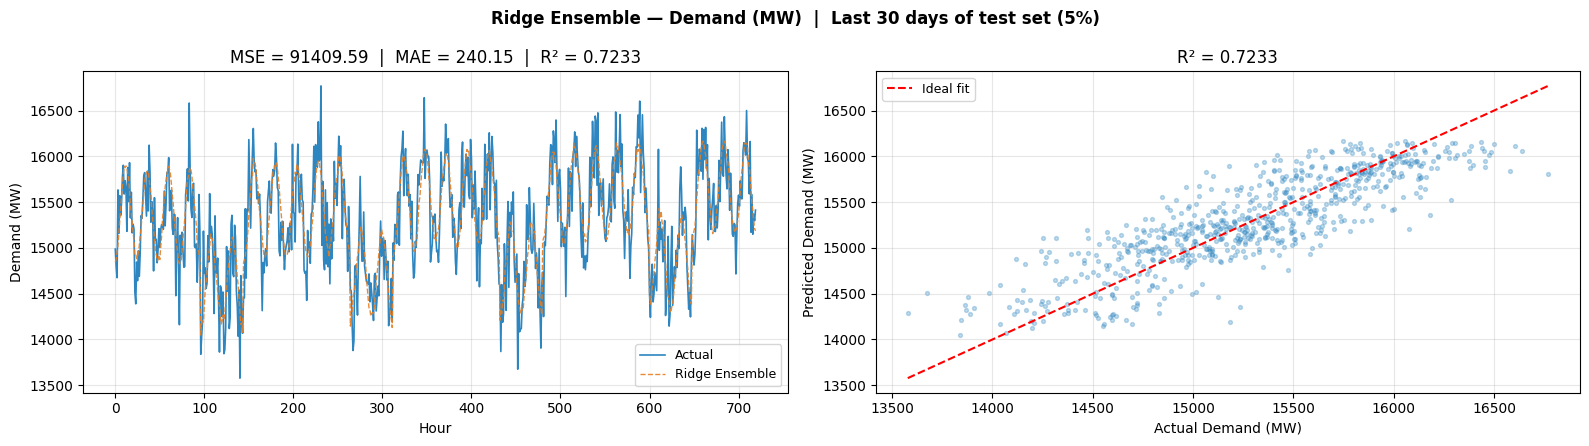

  Saved → omega_viz_demand_test.png


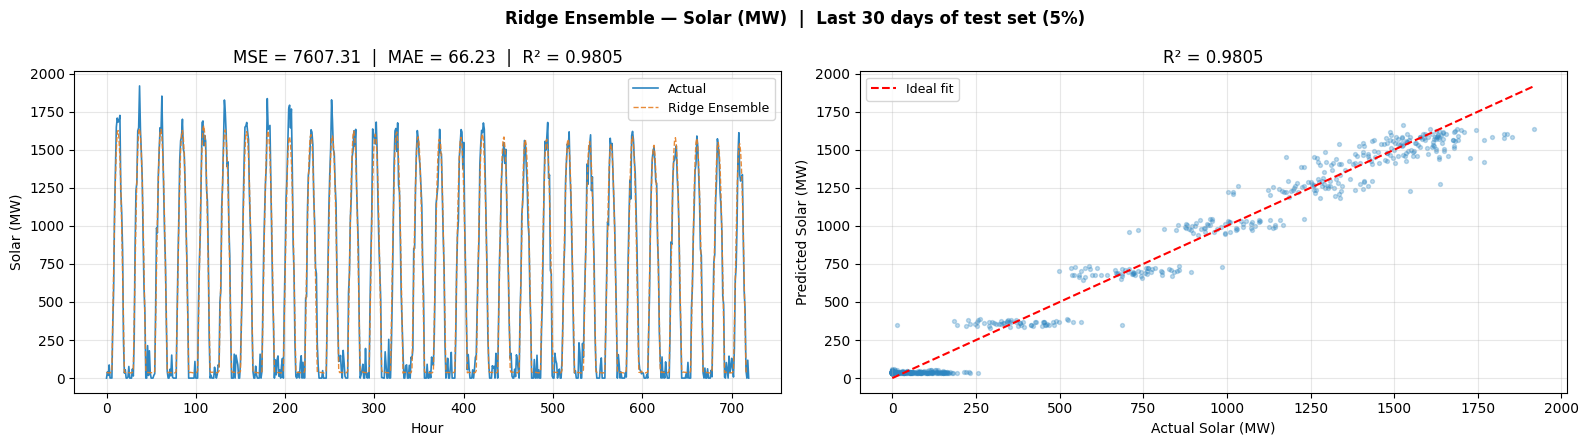

  Saved → omega_viz_solar_test.png


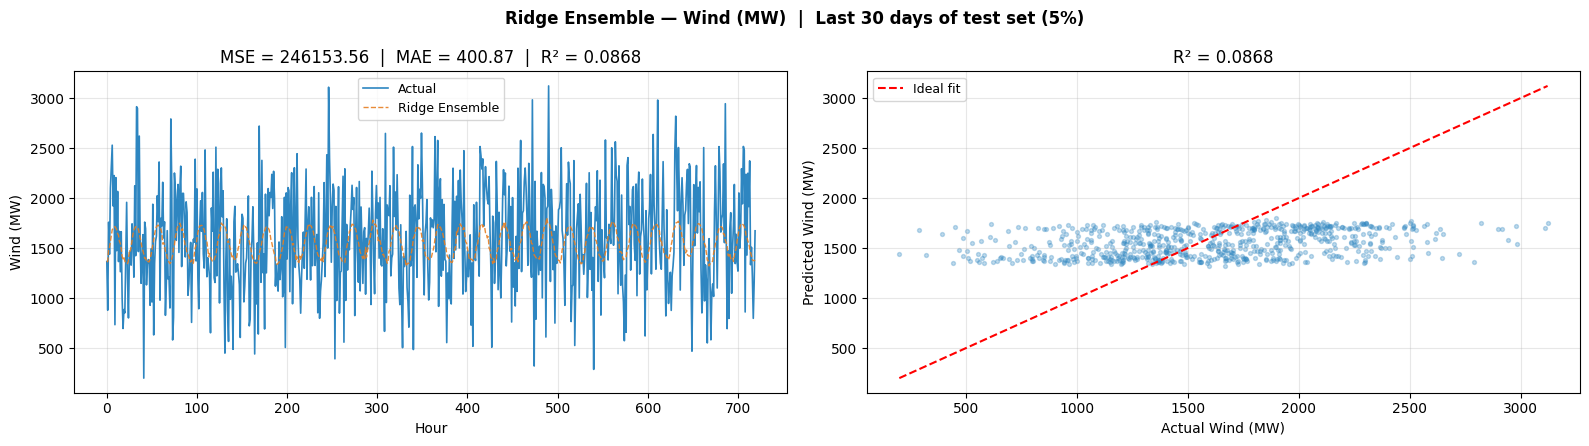

  Saved → omega_viz_wind_test.png


In [22]:
def plot_actual_vs_predicted(target_label, y_te_aln, ens_te,
                             n_days=30, unit='MW'):
    """
    Time-series + scatter comparison: actual vs Ridge Ensemble on test set.
    Shows the last n_days of the test window for readability.
    """
    n_hours  = min(n_days * 24, len(y_te_aln))
    y_plot   = y_te_aln[-n_hours:]
    ens_plot = ens_te[-n_hours:]
    x_axis   = np.arange(len(y_plot))

    mse_ = mean_squared_error(y_plot, ens_plot)
    r2_  = r2_score(y_plot, ens_plot)
    mae_ = mean_absolute_error(y_plot, ens_plot)

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
    fig.suptitle(
        f'Ridge Ensemble — {target_label} ({unit})  '
        f'|  Last {n_hours//24} days of test set (5%)',
        fontsize=12, fontweight='bold'
    )

    # Time series
    axes[0].plot(x_axis, y_plot,   color='#2E86C1', lw=1.2, label='Actual')
    axes[0].plot(x_axis, ens_plot, color='#E67E22', lw=1.0,
                 ls='--', alpha=0.9, label='Ridge Ensemble')
    axes[0].set_xlabel('Hour')
    axes[0].set_ylabel(f'{target_label} ({unit})')
    axes[0].set_title(f'MSE = {mse_:.2f}  |  MAE = {mae_:.2f}  |  R² = {r2_:.4f}')
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # Scatter
    axes[1].scatter(y_plot, ens_plot, alpha=0.3, s=8, color='#2E86C1')
    lims = [min(y_plot.min(), ens_plot.min()),
            max(y_plot.max(), ens_plot.max())]
    axes[1].plot(lims, lims, 'r--', lw=1.5, label='Ideal fit')
    axes[1].set_xlabel(f'Actual {target_label} ({unit})')
    axes[1].set_ylabel(f'Predicted {target_label} ({unit})')
    axes[1].set_title(f'R² = {r2_:.4f}')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f'omega_viz_{target_label.lower()}_test.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {fname}')


plot_actual_vs_predicted('Demand', y_d_te_aln, ens_d_te)
plot_actual_vs_predicted('Solar',  y_s_te_aln, ens_s_te)
plot_actual_vs_predicted('Wind',   y_w_te_aln, ens_w_te)

---
## Step 14 — Predict Date + Export to MILP Optimizer

---
## Step 9 — Layered Historical Reconstruction (Proxy Builder)

To forecast any 2026 date, we need feature rows that represent that future hour.
Since real future data doesn't exist, we build **proxy rows** from historical records
that share the same calendar context, using a **3-layer weighted blend**:

| Layer | Weight | Match criteria |
|-------|--------|----------------|
| 1 | 50% | Same **month + weekday + hour** — most specific |
| 2 | 30% | Same **month + hour** (any weekday) |
| 3 | 20% | Same **season + hour** (any day) — broadest fallback |

**Why only the last 5 years?**  
Ontario's solar capacity grew ~7× from 2015→2025. Including old rows would
systematically underestimate today's solar and wind potential. `PROXY_YEARS_BACK = 5`
keeps the proxy data representative of the current grid.

**LSTM at inference time:**  
The 24 proxy rows (hours 00–23) are stacked into one `(1, 24, n_features)` tensor
and fed to the LSTM, which outputs a single scalar correction. That value is repeated
across all 24 hours — LSTM acts as a **learned bias corrector** capturing the
overall energy level for that day type, while GBM and RF provide per-hour granularity.

In [23]:
SEASON_MAP = {
    1: 'Winter',  2: 'Winter', 12: 'Winter',
    3: 'Spring',  4: 'Spring',  5: 'Spring',
    6: 'Summer',  7: 'Summer',  8: 'Summer',
    9: 'Fall',   10: 'Fall',   11: 'Fall',
}
SEASON_NUM_MAP = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}

PROXY_YEARS_BACK = 5   # Use only the most recent 5 years for averaging

if PROXY_YEARS_BACK is not None:
    _cutoff  = df['datetime'].max() - pd.DateOffset(years=PROXY_YEARS_BACK)
    df_proxy = df[df['datetime'] >= _cutoff].reset_index(drop=True)
    print(f'  Proxy window : last {PROXY_YEARS_BACK} years'
          f'  ({_cutoff.date()} → {df["datetime"].max().date()})'
          f'  — {len(df_proxy):,} rows')
else:
    df_proxy = df
    print(f'  Proxy window : full dataset  ({len(df_proxy):,} rows)')


def build_proxy_row(df_window, hour, month, day_of_week, season, is_weekend):
    """
    Build one proxy feature row for a given hour on a future date.

    Uses a 3-layer weighted blend of historical records:
      Layer 1 (50%) — same month + same weekday + same hour
      Layer 2 (30%) — same month + same hour  (any weekday)
      Layer 3 (20%) — same season + same hour (any day)

    After blending, temporal columns are overwritten with exact
    target-date values so GBM/RF/LSTM see the right calendar context.

    Parameters
    ----------
    df_window   : DataFrame — historical window (last 5 years by default)
    hour        : int  0-23
    month       : int  1-12
    day_of_week : int  0=Mon … 6=Sun
    season      : str  'Winter' | 'Spring' | 'Summer' | 'Fall'
    is_weekend  : int  0 or 1

    Returns
    -------
    pd.Series — one blended feature row
    """
    l1 = df_window[
        (df_window['month']       == month) &
        (df_window['day_of_week'] == day_of_week) &
        (df_window['hour']        == hour)
    ]
    l2 = df_window[
        (df_window['month'] == month) &
        (df_window['hour']  == hour)
    ]
    l3 = df_window[
        (df_window['season'] == season) &
        (df_window['hour']   == hour)
    ]

    # Fallback: if a layer is empty, use the next broader layer
    if len(l1) == 0: l1 = l2
    if len(l2) == 0: l2 = l3

    proxy = (
        0.50 * l1.mean(numeric_only=True) +
        0.30 * l2.mean(numeric_only=True) +
        0.20 * l3.mean(numeric_only=True)
    )

    # Overwrite temporal columns with exact target-date values
    proxy['hour']         = hour
    proxy['month']        = month
    proxy['day_of_week']  = day_of_week
    proxy['is_weekend']   = is_weekend
    proxy['is_peak_hour'] = 1 if (9 <= hour <= 21) else 0
    proxy['season_num']   = SEASON_NUM_MAP[season]

    return proxy


print('  build_proxy_row() defined — 3-layer blend (50% / 30% / 20%)')
print('  Ready to build proxy inputs for any 2026 date.')

  Proxy window : last 5 years  (2020-12-31 → 2025-12-31)  — 43,825 rows
  build_proxy_row() defined — 3-layer blend (50% / 30% / 20%)
  Ready to build proxy inputs for any 2026 date.


---
## Step 10 — Predict for any 2026 Date

**Inference pipeline per date:**
1. Build 24 proxy rows (one per hour) using `build_proxy_row()`
2. Run GBM and RF on each proxy row → 24 per-hour predictions each
3. Stack all 24 proxy rows into `(1, 24, n_features)` → run LSTM → one scalar correction
4. Repeat LSTM scalar across 24 hours → stack with GBM + RF → Ridge → final forecast

In [24]:
def predict_date(date_str):
    """
    Predict hourly Demand, Solar, and Wind for any 2026 date
    using the GBM + RF + LSTM → Ridge stacking ensemble.

    Parameters
    ----------
    date_str : str — 'YYYY-MM-DD', must be within 2026

    Returns
    -------
    dict with keys 'demand', 'solar', 'wind'
    Each value is a list of 24 floats (MW), one per hour (00:00–23:00).
    """
    date        = pd.Timestamp(date_str)
    month       = date.month
    day_of_week = date.dayofweek
    season      = SEASON_MAP[month]
    is_weekend  = 1 if day_of_week >= 5 else 0

    print(f'\n      Date       : {date_str}  ({date.day_name()})')
    print(f'      Season     : {season}  |  '
          f'Weekend: {"Yes" if is_weekend else "No"}')
    print(f'      Peak window: 09:00 – 21:00')
    print('      Building 24 proxy rows ...', end=' ', flush=True)

    # ── Step A: Build proxy DataFrame (24 rows × all features) ─────────
    rows = [
        build_proxy_row(df_proxy, h, month, day_of_week, season, is_weekend)
        for h in range(24)
    ]
    proxy_df = pd.DataFrame(rows)
    proxy_df['hour'] = range(24)
    print('done')

    print('      Running GBM + RF + LSTM → Ridge ...', end=' ', flush=True)

    # ── DEMAND ───────────────────────────────────────────────────────────
    d_gbm = demand_gbm.predict(proxy_df[DEMAND_FEATURES])   # 24 values
    d_rf  = demand_rf.predict(proxy_df[DEMAND_FEATURES])    # 24 values

    # Scale features with X-scaler → reshape to (1,24,n_feat)
    # LSTM outputs [0,1] scaled → inverse_transform back to MW
    d_seq      = scaler_d_X.transform(proxy_df[DEMAND_FEATURES].values)
    d_seq_3d   = d_seq[np.newaxis, :, :]              # (1, 24, n_features)
    d_lstm_sc  = float(demand_lstm.predict(d_seq_3d, verbose=0).flatten()[0])
    d_lstm_val = float(scaler_d_y.inverse_transform([[d_lstm_sc]])[0][0])
    d_lstm     = np.repeat(d_lstm_val, 24)             # bias corrector

    demand_preds = ridge_d.predict(np.column_stack([d_gbm, d_rf, d_lstm]))

    # ── SOLAR ─────────────────────────────────────────────────────────────
    s_gbm = solar_gbm.predict(proxy_df[SOLAR_FEATURES])
    s_rf  = solar_rf.predict(proxy_df[SOLAR_FEATURES])

    s_seq      = scaler_s_X.transform(proxy_df[SOLAR_FEATURES].values)
    s_seq_3d   = s_seq[np.newaxis, :, :]
    s_lstm_sc  = float(solar_lstm.predict(s_seq_3d, verbose=0).flatten()[0])
    s_lstm_val = float(scaler_s_y.inverse_transform([[s_lstm_sc]])[0][0])
    s_lstm     = np.repeat(s_lstm_val, 24)

    solar_preds = np.clip(
        ridge_s.predict(np.column_stack([s_gbm, s_rf, s_lstm])),
        0, None
    )

    # ── WIND ───────────────────────────────────────────────────────────────
    w_gbm = wind_gbm.predict(proxy_df[WIND_FEATURES])
    w_rf  = wind_rf.predict(proxy_df[WIND_FEATURES])

    w_seq      = scaler_w_X.transform(proxy_df[WIND_FEATURES].values)
    w_seq_3d   = w_seq[np.newaxis, :, :]
    w_lstm_sc  = float(wind_lstm.predict(w_seq_3d, verbose=0).flatten()[0])
    w_lstm_val = float(scaler_w_y.inverse_transform([[w_lstm_sc]])[0][0])
    w_lstm     = np.repeat(w_lstm_val, 24)

    wind_preds = np.clip(
        ridge_w.predict(np.column_stack([w_gbm, w_rf, w_lstm])),
        0, None
    )

    print('done ✓')

    return {
        'demand': [round(float(v), 1) for v in demand_preds],
        'solar':  [round(float(v), 1) for v in solar_preds],
        'wind':   [round(float(v), 1) for v in wind_preds],
    }


def print_summary(date_str, results):
    """Print a rich 24-hour forecast table with Renewable % column."""
    demand = results['demand']
    solar  = results['solar']
    wind   = results['wind']

    print('\n' + '=' * 70)
    print(f'  24-HOUR FORECAST  —  {date_str}  (GBM + RF + LSTM → Ridge)')
    print('=' * 70)
    print(f'  {"Hour":<7}  {"Demand (MW)":>12}  {"Solar (MW)":>11}'
          f'  {"Wind (MW)":>10}  {"Renew %":>8}')
    print('  ' + '─' * 65)

    for h in range(24):
        renew_pct = (solar[h] + wind[h]) / max(demand[h], 1) * 100
        flag      = ' ◄' if (9 <= h <= 21) else '   '
        print(
            f'  {h:02d}:00{flag}  '
            f'{demand[h]:>12,.0f}  '
            f'{solar[h]:>11,.0f}  '
            f'{wind[h]:>10,.0f}  '
            f'{renew_pct:>7.1f}%'
        )

    avg_d = sum(demand) / 24
    avg_s = sum(solar)  / 24
    avg_w = sum(wind)   / 24
    print('  ' + '─' * 65)
    print(f'  {"AVERAGE":<7}  {avg_d:>12,.0f}  {avg_s:>11,.0f}  {avg_w:>10,.0f}')
    print(f'\n  ◄ = peak hours (09:00 – 21:00)')
    print(f'\n  DEMAND  peak  : {max(demand):>8,.0f} MW  at {demand.index(max(demand)):02d}:00')
    print(f'  DEMAND  trough: {min(demand):>8,.0f} MW  at {demand.index(min(demand)):02d}:00')
    print(f'  SOLAR   peak  : {max(solar):>8,.0f} MW  at {solar.index(max(solar)):02d}:00')
    print(f'  WIND    avg   : {avg_w:>8,.0f} MW  (range {min(wind):,.0f} – {max(wind):,.0f} MW)')
    print('=' * 70)


def plot_forecast(date_str, results):
    """Dark-themed 3-panel chart saved as PNG."""
    demand = results['demand']
    solar  = results['solar']
    wind   = results['wind']
    hours  = list(range(24))
    labels = [f'{h:02d}:00' for h in hours]

    fig = plt.figure(figsize=(15, 9))
    fig.patch.set_facecolor('#0f1117')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
    gkw = dict(color='#2a3050', linestyle='--', linewidth=0.5, alpha=0.7)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.set_facecolor('#181c27')
    ax1.fill_between(hours, demand, alpha=0.13, color='#5c7cfa')
    ax1.plot(hours, demand, color='#5c7cfa', linewidth=2.5, label='Demand (MW)')
    ax1.axvspan(9, 21, alpha=0.05, color='#5c7cfa', label='Peak window')
    mh = demand.index(max(demand))
    ax1.annotate(
        f'Peak  {max(demand):,.0f} MW',
        xy=(mh, max(demand)), xytext=(mh + 1.5, max(demand) + 60),
        color='white', fontsize=9,
        arrowprops=dict(arrowstyle='->', color='#aab4fb', lw=1.2),
    )
    ax1.set_title(f'Demand — {date_str}  (GBM + RF + LSTM → Ridge)',
                  color='white', fontsize=12, pad=10)
    ax1.set_ylabel('MW', color='#7b83b0', fontsize=10)
    ax1.set_xticks(hours[::2])
    ax1.set_xticklabels(labels[::2], color='#7b83b0', fontsize=8)
    ax1.tick_params(colors='#7b83b0')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax1.grid(**gkw); ax1.spines[:].set_color('#2a3050')
    ax1.legend(facecolor='#181c27', labelcolor='white', fontsize=9)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.set_facecolor('#181c27')
    ax2.fill_between(hours, solar, alpha=0.18, color='#fbbf24')
    ax2.plot(hours, solar, color='#fbbf24', linewidth=2, label='Solar (MW)')
    ms = solar.index(max(solar))
    if max(solar) > 10:
        ax2.annotate(
            f'{max(solar):,.0f} MW',
            xy=(ms, max(solar)), xytext=(max(ms - 3, 1), max(solar) * 0.82),
            color='#fbbf24', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#fbbf24', lw=1),
        )
    ax2.set_title('Solar  (GBM + RF + LSTM → Ridge)', color='white', fontsize=11, pad=8)
    ax2.set_ylabel('MW', color='#7b83b0', fontsize=10)
    ax2.set_xticks(hours[::4])
    ax2.set_xticklabels(labels[::4], color='#7b83b0', fontsize=8)
    ax2.tick_params(colors='#7b83b0')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax2.grid(**gkw); ax2.spines[:].set_color('#2a3050')
    ax2.legend(facecolor='#181c27', labelcolor='white', fontsize=9)

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.set_facecolor('#181c27')
    ax3.fill_between(hours, wind, alpha=0.18, color='#34d399')
    ax3.plot(hours, wind, color='#34d399', linewidth=2, label='Wind (MW)')
    ax3.set_title('Wind  (GBM + RF + LSTM → Ridge)', color='white', fontsize=11, pad=8)
    ax3.set_ylabel('MW', color='#7b83b0', fontsize=10)
    ax3.set_xticks(hours[::4])
    ax3.set_xticklabels(labels[::4], color='#7b83b0', fontsize=8)
    ax3.tick_params(colors='#7b83b0')
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax3.grid(**gkw); ax3.spines[:].set_color('#2a3050')
    ax3.legend(facecolor='#181c27', labelcolor='white', fontsize=9)

    fig.suptitle(
        f'OMEGA — 24-Hour Forecast  |  {date_str}  |  GBM + RF + LSTM → Ridge',
        color='white', fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    fname = f'forecast_{date_str}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print(f'  Chart saved → {fname}')


print('  predict_date(), print_summary(), plot_forecast() — all defined.')


  predict_date(), print_summary(), plot_forecast() — all defined.


  All models ready  (GBM + RF + LSTM → Ridge).
  Enter any date in 2026 to get a 24-hour prediction.
  Format : YYYY-MM-DD    Example : 2026-07-15
  Type 'q' to quit.



  Enter date:  2026-06010


  Cannot parse that date. Use YYYY-MM-DD, e.g. 2026-03-21



  Enter date:  2026-06-10



  Building proxy inputs and running GBM + RF + LSTM → Ridge...

      Date       : 2026-06-10  (Wednesday)
      Season     : Summer  |  Weekend: No
      Peak window: 09:00 – 21:00
      Building 24 proxy rows ... done
      Running GBM + RF + LSTM → Ridge ... done ✓

  24-HOUR FORECAST  —  2026-06-10  (GBM + RF + LSTM → Ridge)
  Hour      Demand (MW)   Solar (MW)   Wind (MW)   Renew %
  ─────────────────────────────────────────────────────────────────
  00:00           15,791           36         694      4.6%
  01:00           15,802           36         708      4.7%
  02:00           15,877           36         724      4.8%
  03:00           15,889           36         753      5.0%
  04:00           15,948           36         773      5.1%
  05:00           15,966           36         809      5.3%
  06:00           16,042           36         828      5.4%
  07:00           16,081           45         834      5.5%
  08:00           16,143           76         852      5.8%
 


  Show chart? (y/n):  y


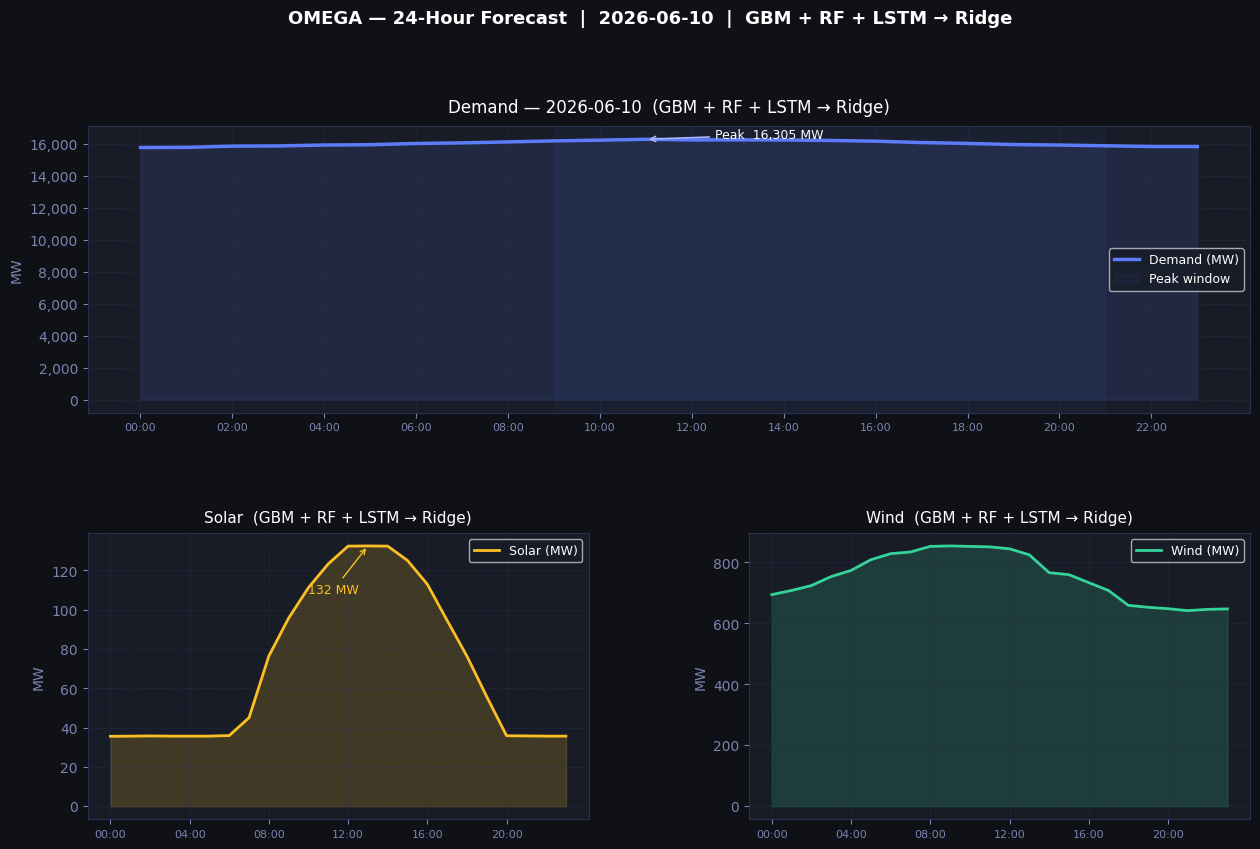

  Chart saved → forecast_2026-06-10.png



  Export to CSV for MILP optimizer? (y/n):  y


  ✓ Forecast saved for MILP optimizer → ./forecast_for_milp_2026-06-10.csv
    24 rows, columns: hour, demand, solar, wind  (all in MW)



  Predict another date? (y/n):  n



  Done. Goodbye!



In [28]:
print('  All models ready  (GBM + RF + LSTM → Ridge).')
print('  Enter any date in 2026 to get a 24-hour prediction.')
print('  Format : YYYY-MM-DD    Example : 2026-07-15')
print("  Type 'q' to quit.\n")

while True:
    date_input = input('  Enter date: ').strip()

    if date_input.lower() in ('q', 'quit', 'exit'):
        print('\n  Goodbye!\n')
        break

    try:
        parsed_date = pd.Timestamp(date_input)
    except Exception:
        print('  Cannot parse that date. Use YYYY-MM-DD, e.g. 2026-03-21\n')
        continue

    if parsed_date.year != 2026:
        print('  Please enter a date in 2026 (2026-01-01 to 2026-12-31).\n')
        continue

    print(f'\n  Building proxy inputs and running GBM + RF + LSTM → Ridge...')
    results = predict_date(date_input)

    print_summary(date_input, results)

    if input('\n  Show chart? (y/n): ').strip().lower() == 'y':
        plot_forecast(date_input, results)

    if input('\n  Export to CSV for MILP optimizer? (y/n): ').strip().lower() == 'y':
        export_to_milp(date_input, results)

    if input('\n  Predict another date? (y/n): ').strip().lower() != 'y':
        print('\n  Done. Goodbye!\n')
        break

---
## Step 11 — Export CSV for MILP Optimizer

Save the 24-hour forecast as a CSV file that feeds directly into the
OMEGA Linear Programming dispatch optimizer.
Columns: `hour | demand | solar | wind`  (all in MW)

In [26]:
def export_to_milp(date_str, results, out_dir='.'):
    """
    Save the 24-hour forecast as a CSV for the MILP optimizer.
    Columns: hour, demand, solar, wind  (all in MW).
    """
    import os
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f'forecast_for_milp_{date_str}.csv')

    pd.DataFrame({
        'hour'  : list(range(24)),
        'demand': results['demand'],
        'solar' : results['solar'],
        'wind'  : results['wind'],
    }).to_csv(out_path, index=False)

    print(f'  ✓ Forecast saved for MILP optimizer → {out_path}')
    print(f'    24 rows, columns: hour, demand, solar, wind  (all in MW)')
    return out_path